## Product_Type: 2 데이터 EDA

## 프로젝트 개요 및 환경 설정

### 라이브러리 설치 및 Import

In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


### 데이터 로드

In [3]:
# 데이터 로드
df = pd.read_csv('ptype_2.csv')
df.columns = df.columns.str.strip()

print("="*60)
print("데이터 로드 완료!")
print("="*60)

데이터 로드 완료!


## 데이터 이해

### 데이터 구조 파악

In [4]:
print("\n" + "="*60)
print("Product_Type이 2인 데이터")
print("="*60)
print(df.shape)
print("\n[Data Info]")
df.info()


Product_Type이 2인 데이터
(1964, 56)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 56 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Type               1964 non-null   int64  
 1   Shot                       1964 non-null   int64  
 2   Velocity_1                 1964 non-null   float64
 3   Velocity_2                 1964 non-null   float64
 4   Velocity_3                 1964 non-null   float64
 5   High_Velocity              1964 non-null   float64
 6   Cylinder_Pressure          1964 non-null   int64  
 7   Rapid_Rise_Time            1964 non-null   float64
 8   Biscuit_Thickness          1964 non-null   int64  
 9   Clamping_Force             1964 non-null   int64  
 10  Cycle_Time                 1964 non-null   float64
 11  Pressure_Rise_Time         1964 non-null   float64
 12  Casting_Pressure           1964 non-null   int64  
 13  Spray_Time   

### 컬럼별 의미 및 데이터 타입 확인

In [5]:
# =======================================================
# DieCasting 주요 컬럼 설명
# =======================================================
# [공정 변수]
# • id                            : 고유 식별자 (각 Shot에 부여된 고유 ID (연속적이지 않음))
# • Product_Type                  : 제품 유형 (생산 제품 종류 구분 (1: 4,207건 / 2: 3,328건))
# • Shot                          : 샷 번호 (해당 제품 유형 내 순차 주조 번호)
# • Velocity_1                    : 1단계 사출 속도 (저속 구간 초기 사출 속도)
# • Velocity_2                    : 2단계 사출 속도 (중속 구간 사출 속도 (이상치 184건))
# • Velocity_3                    : 3단계 사출 속도 (고속 구간 사출 속도)
# • High_Velocity                 : 최고 사출 속도 (사출 최대 순간 속도)
# • Cylinder_Pressure             : 실린더 압력 (사출 실린더 내부 유압)
# • Rapid_Rise_Time               : 급속 상승 시간 (압력이 급속 상승하는 데 걸리는 시간)
# • Biscuit_Thickness             : 비스킷 두께 (주조 후 게이트 잔여 두께)
# • Clamping_Force                : 형체력 (금형을 닫는 데 가해지는 힘)
# • Cycle_Time                    : 사이클 시간 (1 Shot 완료까지 걸리는 총 시간)
# • Pressure_Rise_Time            : 압력 상승 시간 (주조 압력이 목표값까지 상승하는 시간)
# • Casting_Pressure              : 주조 압력 (용탕 금형 충전 시 가해지는 압력)
# • Spray_Time                    : 스프레이 시간(합계) (이형제 분사 총 시간)
# • Spray_1_Time                  : 스프레이 1 시간 (이형제 1차 분사 시간)
# • Spray_2_Time                  : 스프레이 2 시간 (이형제 2차 분사 시간)
# =======================================================
# [센서 변수]
# • Melting_Furnace_Temp          : 용해로 온도 (용탕을 녹이는 용해로 내부 온도)
# • Air_Pressure                  : 공기 압력 (설비 구동용 압축 공기 압력 (실측값))
# • Air_Pressure_Min              : 공기 압력 최솟값 (압축 공기 압력 하한 기준값)
# • Air_Pressure_Max              : 공기 압력 최댓값 (압축 공기 압력 상한 기준값)
# • Coolant_Temp                  : 냉각수 온도 (금형 냉각용 냉각수 실측 온도)
# • Coolant_Temp_Min              : 냉각수 온도 최솟값 (냉각수 온도 하한 기준값)
# • Coolant_Temp_Max              : 냉각수 온도 최댓값 (냉각수 온도 상한 기준값)
# • Coolant_Pressure              : 냉각수 압력 (냉각수 순환 압력)
# • Factory_Temp                  : 공장 온도 (공장 내부 환경 온도 (결측 90건))
# • Factory_Temp_Min              : 공장 온도 최솟값 (공장 온도 하한 기준값)
# • Factory_Temp_Max              : 공장 온도 최댓값 (공장 온도 상한 기준값)
# • Factory_Humidity              : 공장 습도 (공장 내부 습도 (결측 90건))
# • Factory_Humidity_Min          : 공장 습도 최솟값 (공장 습도 하한 기준값)
# • Factory_Humidity_Max          : 공장 습도 최댓값 (공장 습도 상한 기준값)
# =======================================================
# [불량 변수]
# • Short_Shot_1 / _2             : 미성형 (용탕이 금형 내부를 완전히 채우지 못해 형상 미완성 — Part 1/2 각각)
# • Bubble_1 / _2                 : 기포 (금형 충전 시 공기 혼입으로 표면 또는 내부에 기포 발생)
# • Exfoliation_1 / _2            : 박리 (표면층이 얇게 벗겨지는 현상)
# • Blow_Hole_1 / _2              : 기공 (응고 과정의 가스/수축으로 내부에 생긴 빈 공간)
# • Stain_1 / _2                  : 얼룩 (표면 오염이나 산화로 인한 변색·얼룩)
# • Dent_1 / _2                   : 함몰 (표면 국소 함몰)
# • Deformation_1 / _2            : 변형 (제품 치수/형상 변형)
# • Contamination_1 / _2          : 오염 (외부 이물질에 의한 오염)
# • Impurity_1 / _2               : 불순물 (원재료·공정상 혼입 불순물)
# • Crack_1 / _2                  : 균열 (표면 또는 내부 크랙)
# • Buring_Mark_1 / _2            : 소착 자국 (금형과의 소착(눌어붙음)으로 생긴 자국)
# • Inclusions_1 / _2             : 개재물 (금속 내 비금속 개재물 혼입 (발생 0건))


### 기초 통계량 확인

In [6]:
print("\n" + "="*60)
print("DieCasting 기초 통계")
print("="*60)
display(df.describe(include='all'))


DieCasting 기초 통계


,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Exfoliation_1,Blow_Hole_1,Stain_1,Dent_1,Deformation_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Inclusions_1,Short_Shot_2,Bubble_2,Exfoliation_2,Blow_Hole_2,Stain_2,Dent_2,Deformation_2,Contamination_2,Impurity_2,Crack_2,Scratch_2,Buring_Mark_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
count,1964.0,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.00000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.0,1964.000000,1964.000000,1964.000000,1964.0,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.0,1964.000000,1964.0,1964.0,1964.000000,1964.0,1964.000000,1964.0,1964.000000,1964.000000,1964.000000,1964.0,1964.0,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1467
mean,2.0,337.792261,0.154493,0.168430,0.202365,2.576213,264.714358,0.011692,17.537678,368.371690,35.508910,0.037234,595.350815,11.533910,2.022709,2.24333,655.655143,6.139409,26.909878,2.691314,33.010081,61.276222,0.093177,0.000509,0.0,0.063136,0.052444,0.002037,0.0,0.002037,0.001018,0.000509,0.001018,0.002546,0.0,0.024949,0.0,0.0,0.041752,0.0,0.002037,0.0,0.004073,0.002546,0.001018,0.0,0.0,0.000509,330.636456,2.249035,0.013937,0.033935,2.373848,2.421720,0.253055,NaN
std,0.0,195.490862,0.004829,0.004079,0.005094,0.085683,0.738559,0.000889,1.529505,10.615799,2.400543,0.003088,1.507544,0.958216,0.100247,0.33964,8.942808,0.649703,0.534318,0.052276,1.769415,7.615451,0.302771,0.022565,0.0,0.269120,0.244760,0.045095,0.0,0.045095,0.031903,0.022565,0.031903,0.050405,0.0,0.159242,0.0,0.0,0.207570,0.0,0.045095,0.0,0.063709,0.050405,0.031903,0.0,0.0,0.022565,0.925231,0.002974,0.006473,0.006589,0.085381,0.085761,0.434873,NaN
min,2.0,0.000000,0.139000,0.158000,0.184000,2.470000,247.000000,0.009000,2.000000,346.000000,33.600000,0.031000,556.000000,8.000000,2.000000,2.00000,635.300000,4.600000,25.900000,2.580000,27.400000,45.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,309.000000,2.242424,-0.002000,0.012000,2.267000,2.310000,0.000000,NaN
25%,2.0,169.750000,0.152000,0.165000,0.200000,2.516000,264.000000,0.011000,17.000000,357.000000,34.000000,0.035000,595.000000,10.100000,2.000000,2.00000,648.500000,5.700000,26.500000,2.630000,31.900000,54.075000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,330.000000,2.245283,0.010000,0.030000,2.314000,2.361750,0.000000,NaN
50%,2.0,334.000000,0.156000,0.168000,0.202000,2.528000,265.000000,0.012000,18.000000,37

### 고유값 확인

In [7]:
print("\n" + "="*60)
print("DieCasting 컬럼별 고유값 개수")
print("="*60)
print(df.nunique())



DieCasting 컬럼별 고유값 개수
Product_Type                   1
Shot                         733
Velocity_1                    20
Velocity_2                    16
Velocity_3                    26
High_Velocity                155
Cylinder_Pressure              6
Rapid_Rise_Time                6
Biscuit_Thickness             14
Clamping_Force                24
Cycle_Time                    31
Pressure_Rise_Time            14
Casting_Pressure              11
Spray_Time                    16
Spray_1_Time                   3
Spray_2_Time                   5
Melting_Furnace_Temp         323
Air_Pressure                  26
Coolant_Temp                  23
Coolant_Pressure              22
Factory_Temp                  67
Factory_Humidity             210
Short_Shot_1                   3
Bubble_1                       2
Exfoliation_1                  1
Blow_Hole_1                    4
Stain_1                        3
Dent_1                         2
Deformation_1                  1
Contamination_1     

## 데이터 전처리

> 수빈님이 전처리 해주신 내용에 더해,  
> **Product_Type: 2 기준 불량 이력이 없는 컬럼만 추가 제거 진행**

### describe 기준으로 값이 없는 컬럼 확인해서 제거

In [8]:
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Type,1964.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0
Shot,1964.0,NaN,NaN,NaN,337.792261,195.490862,0.0,169.75,334.0,500.25,732.0
Velocity_1,1964.0,NaN,NaN,NaN,0.154493,0.004829,0.139,0.152,0.156,0.158,0.162
Velocity_2,1964.0,NaN,NaN,NaN,0.16843,0.004079,0.158,0.165,0.168,0.172,0.178
Velocity_3,1964.0,NaN,NaN,NaN,0.202365,0.005094,0.184,0.2,0.202,0.206,0.216
High_Velocity,1964.0,NaN,NaN,NaN,2.576213,0.085683,2.47,2.516,2.528,2.68825,2.744
Cylinder_Pressure,1964.0,NaN,NaN,NaN,264.714358,0.738559,247.0,264.0,265.0,265.0,266.0
Rapid_Rise_Time,1964.0,NaN,NaN,NaN,0.011692,0.000889,0.009,0.011,0.012,0.012,0.014
Biscuit_Thickness,1964.0,NaN,NaN,NaN,17.537678,1.529505,2.0,17.0,18.0,19.0,24.0
Clamping_Force,1964.0,NaN,NaN,NaN,368.37169,10.615799,346.0,357.0,370.0,379.0,388.0


#### Product_Type: 2 에서 불량 이력이 없는 컬럼 목록
- Exfoliation_1
- Deformation_1
- Inclusions_1
- Bubble_2
- Exfoliation_2
- Stain_2
- Deformation_2
- Scratch_2
- Buring_Mark_2

**→ 총 9개 컬럼**

In [9]:
df_drop = df.drop(columns=['Exfoliation_1', 'Deformation_1', 'Inclusions_1', 'Bubble_2', 'Exfoliation_2', 'Stain_2', 'Deformation_2', 'Scratch_2', 'Buring_Mark_2'])

In [10]:
print(f"기존: {df.shape}")
print(f"제거 후: {df_drop.shape}")
print(f"컬럼 수 {df.shape[1] - df_drop.shape[1]}개 감소")

기존: (1964, 56)
제거 후: (1964, 47)
컬럼 수 9개 감소


### 중복 데이터 확인

In [11]:
# 전체 중복
print("전체 중복 행:", df_drop.duplicated().sum())

전체 중복 행: 0


In [12]:
df_drop.describe()

,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Short_Shot_1,Bubble_1,Blow_Hole_1,Stain_1,Dent_1,Contamination_1,Impurity_1,Crack_1,Scratch_1,Buring_Mark_1,Short_Shot_2,Blow_Hole_2,Dent_2,Contamination_2,Impurity_2,Crack_2,Inclusions_2,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status
count,1964.0,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.00000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000,1964.000000
mean,2.0,337.792261,0.154493,0.168430,0.202365,2.576213,264.714358,0.011692,17.537678,368.371690,35.508910,0.037234,595.350815,11.533910,2.022709,2.24333,655.655143,6.139409,26.909878,2.691314,33.010081,61.276222,0.093177,0.000509,0.063136,0.052444,0.002037,0.002037,0.001018,0.000509,0.001018,0.002546,0.024949,0.041752,0.002037,0.004073,0.002546,0.001018,0.000509,330.636456,2.249035,0.013937,0.033935,2.373848,2.421720,0.253055
std,0.0,195.490862,0.004829,0.004079,0.005094,0.085683,0.738559,0.000889,1.529505,10.615799,2.400543,0.003088,1.507544,0.958216,0.100247,0.33964,8.942808,0.649703,0.534318,0.052276,1.769415,7.615451,0.302771,0.022565,0.269120,0.244760,0.045095,0.045095,0.031903,0.022565,0.031903,0.050405,0.159242,0.207570,0.045095,0.063709,0.050405,0.031903,0.022565,0.925231,0.002974,0.006473,0.006589,0.085381,0.085761,0.434873
min,2.0,0.000000,0.139000,0.158000,0.184000,2.470000,247.000000,0.009000,2.000000,346.000000,33.600000,0.031000,556.000000,8.000000,2.000000,2.00000,635.300000,4.600000,25.900000,2.580000,27.400000,45.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,309.000000,2.242424,-0.002000,0.012000,2.267000,2.310000,0.000000
25%,2.0,169.750000,0.152000,0.165000,0.200000,2.516000,264.000000,0.011000,17.000000,357.000000,34.000000,0.035000,595.000000,10.100000,2.000000,2.00000,648.500000,5.700000,26.500000,2.630000,31.900000,54.075000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,330.000000,2.245283,0.010000,0.030000,2.314000,2.361750,0.000000
50%,2.0,334.000000,0.156000,0.168000,0.202000,2.528000,265.000000,0.012000,18.000000,370.000000,35.900000,0.036000,595.000000,12.100000,2.000000,2.00000,655.400000,6.200000,26.800000,2.700000,32.200000,62.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,331.000000,2.249057,0.014000,0.034000,2.326000,2.374000,0.000000
75%,2.0,500.250000,0.158000,0.172000,0.206000,2.688250,265.000000,0.012000,19.000000,379.000000,36.100000,0.040000,596.000000,12.100000,2.000000,2.70000,662.700000,6.700000,27.200000,2.740000,34.500000,68.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,331.000000,2.250000,0.018000,0.038000,2.485000,2.533000,1.000000
max,2.0,732.000000,0.162000,0.178000,0.216000,2.744000,266.000000,0.014000,24.000000,388.000000,125.900000,0.045000,597.000000,13.100000,2.500000,3.00000,678.100000,7.100000,28.100000,2.790000,37.000000,72.300000,2.000000,1.000000,3.000000,2.000000,1.000000,1.000000,

### 결측치 확인

In [13]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

missing_df = pd.DataFrame({
    '결측수': df_drop.isnull().sum(),
    '결측비율(%)': (df_drop.isnull().sum() / len(df) * 100).round(2)
})
missing_df = missing_df[missing_df['결측수'] > 0].sort_values('결측수', ascending=False)

if len(missing_df) > 0:
    print("\n[결측치 현황]")
    display(missing_df)
else:
    print("\n결측치 없음")



결측치 확인

결측치 없음


> **중복 데이터도 없고, 불량 데이터가 존재하지 않는 컬럼도 제거!**  
> **결측치는 튜터님 미팅 후 어떻게 할지 결정**  
> **이 상태에서 이후 단계 진행**

### 이상치 확인 및 처리

In [14]:
# 이상치 탐지 함수
def detect_outliers_iqr(dataframe, cols):
    outlier_info = {}
    for col in cols:
        Q1, Q3 = dataframe[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        outlier_info[col] = {
            'count': mask.sum(),
            'pct(%)': f"{mask.mean()*100:.2f}",
            'lower_bound': round(lower, 4),
            'upper_bound': round(upper, 4)
        }
    result = pd.DataFrame(outlier_info).T.sort_values('count', ascending=False)
    return result[result['count'] > 0]

process_num_cols = [
    'Velocity_1','Velocity_2','Velocity_3','High_Velocity',
    'Cylinder_Pressure','Rapid_Rise_Time','Biscuit_Thickness',
    'Clamping_Force','Cycle_Time','Pressure_Rise_Time',
    'Casting_Pressure','Spray_Time','Spray_1_Time','Spray_2_Time'
]

# ── 분산=0 또는 IQR=0 변수 사전 확인 → Capping 대상에서 제외
zero_var_cols = []
for col in process_num_cols:
    Q1, Q3 = df_drop[col].quantile(0.25), df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    if df_drop[col].std() == 0 or df_drop[col].nunique() <= 1 or IQR == 0:
        zero_var_cols.append(col)

if zero_var_cols:
    print(f"⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: {zero_var_cols}")
    for col in zero_var_cols:
        print(f"     {col}: 고유값={df_drop[col].nunique()}, IQR={df_drop[col].quantile(0.75)-df_drop[col].quantile(0.25):.4f}")
else:
    print("✅ 분산=0 / IQR=0 변수 없음")

# Capping 가능한 컬럼만 추출 (IQR=0 + Cycle_Time 제외)
cap_cols = [c for c in process_num_cols if c != 'Cycle_Time' and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

print("\n[ Process 변수 이상치 탐지 (IQR=0 제외) ]")
display(detect_outliers_iqr(df_drop, cap_cols))
print("\n※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)")
if zero_var_cols:
    print(f"※ {zero_var_cols} → IQR=0으로 Capping 제외 (이후 피처에서도 제거)")

⚠️  IQR=0 또는 분산=0 변수 발견 → Capping 대상 제외: ['Spray_1_Time']
     Spray_1_Time: 고유값=3, IQR=0.0000

Capping 대상 컬럼 (12개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_2_Time']

[ Process 변수 이상치 탐지 (IQR=0 제외) ]


,count,pct(%),lower_bound,upper_bound
Rapid_Rise_Time,145,7.38,0.0095,0.0135
Velocity_3,50,2.55,0.191,0.215
Velocity_1,36,1.83,0.143,0.167
Casting_Pressure,33,1.68,593.5,597.5
Biscuit_Thickness,17,0.87,14.0,22.0
Cylinder_Pressure,6,0.31,262.5,266.5



※ Cycle_Time → Capping 제외 (공정 지연 신호 유지)
※ ['Spray_1_Time'] → IQR=0으로 Capping 제외 (이후 피처에서도 제거)


In [15]:
df_drop['Rapid_Rise_Time'].describe()

count    1964.000000
mean        0.011692
std         0.000889
min         0.009000
25%         0.011000
50%         0.012000
75%         0.012000
max         0.014000
Name: Rapid_Rise_Time, dtype: float64

- IQR 기준(단위: Sec)
    - Lower_Bound = 0.0095
    - Upper_Bound = 0.0135
- Min, Max 값(단위: Sec)
    - Min = 0.0090
    - Max = 0.0140  

> 범위 자체도 매우 좁고, IQR과 실제 Min, Max 값의 수치 차이가 미미함  
> → 공정 내에서 센서 노이즈나 환경 영향으로 저 정도 수준의 변동은 자연스럽다고 판단하여 **이상치로 처리하지 않음**

In [16]:
# Cap_cols 수정 (Rapid_Rise_Time 추가 제외)
exclude_cols = {'Cycle_Time', 'Rapid_Rise_Time'}
cap_cols = [c for c in process_num_cols if c not in exclude_cols and c not in zero_var_cols]
print(f"\nCapping 대상 컬럼 ({len(cap_cols)}개): {cap_cols}")

# 절사 기준 비교 (cap_cols 기준 — 분산=0 이미 제외됨)
def count_outliers(dataframe, cols, method='iqr', pct=0.01):
    result = {}
    for col in cols:
        if method == 'iqr':
            Q1, Q3 = dataframe[col].quantile(0.25), dataframe[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        else:
            lower = dataframe[col].quantile(pct)
            upper = dataframe[col].quantile(1 - pct)
        result[col] = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    return pd.Series(result)

compare_df = pd.DataFrame({
    'IQR':  count_outliers(df_drop, cap_cols, 'iqr'),
    '1%':   count_outliers(df_drop, cap_cols, 'pct', 0.01),
    '0.5%': count_outliers(df_drop, cap_cols, 'pct', 0.005),
}).sort_values('IQR', ascending=False)

print("[ 절사 기준별 이상치 건수 비교 ]")
print("(분산=0 변수 및 Cycle_Time 제외)")
display(compare_df[compare_df.sum(axis=1) > 0])

# IQR Capping 적용
outlier_report = []
for col in cap_cols:
    Q1, Q3 = df_drop[col].quantile(0.25), df_drop[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    cnt = ((df_drop[col] < lower) | (df_drop[col] > upper)).sum()
    if cnt > 0:
        outlier_report.append({'변수': col, '이상치 수': cnt})
    df_drop[col] = df_drop[col].clip(lower, upper)  # clip은 lower or upper bound 값으로 이상치를 변경

print("\n✅ IQR Capping 완료:")
for r in outlier_report:
    flag = " ⚠️ 추가 조사 중" if r['변수'] == 'Velocity_2' else ""
    print(f"   - {r['변수']}: {r['이상치 수']}건{flag}")
if zero_var_cols:
    print(f"   - {zero_var_cols}: 분산=0으로 Capping 미적용")
print(f"\n최종 데이터: {df_drop.shape[0]}행 × {df_drop.shape[1]}열")



Capping 대상 컬럼 (11개): ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Biscuit_Thickness', 'Clamping_Force', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_2_Time']
[ 절사 기준별 이상치 건수 비교 ]
(분산=0 변수 및 Cycle_Time 제외)


,IQR,1%,0.5%
Velocity_3,50,24,16
Velocity_1,36,14,4
Casting_Pressure,33,16,9
Biscuit_Thickness,17,20,10
Cylinder_Pressure,6,7,7
Velocity_2,0,22,2
High_Velocity,0,40,15
Clamping_Force,0,27,16
Pressure_Rise_Time,0,15,12
Spray_Time,0,12,12



✅ IQR Capping 완료:
   - Velocity_1: 36건
   - Velocity_3: 50건
   - Cylinder_Pressure: 6건
   - Biscuit_Thickness: 17건
   - Casting_Pressure: 33건
   - ['Spray_1_Time']: 분산=0으로 Capping 미적용

최종 데이터: 1964행 × 47열


> capping => clip을 사용해서 이상치는 처리하되, 행 갯수는 유지함

## 타겟 변수 및 파생 변수 생성

In [17]:
# # ① 불량 관련 컬럼 자동 수집
# # 컬럼명이 불량 유형으로 시작하는 것들만 골라냄
# defect_cols_all = [c for c in df_drop.columns if any(c.startswith(d) for d in [
#     'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
#     'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
# ])]

# # ② 불량 여부 (0/1) 생성
# # 불량 컬럼 중 하나라도 1이면 불량(1), 전부 0이면 양품(0)
# df_drop['Defect_Status'] = (df_drop[defect_cols_all].sum(axis=1) > 0).astype(int)

# # ③ 불량 유형별 컬럼 매핑
# # 어떤 컬럼이 어떤 불량 유형인지 딕셔너리로 정의
# defect_types = {
#     'Short_Shot':  ['Short_Shot_1','Short_Shot_2'],
#     'Blow_Hole':   ['Blow_Hole_1','Blow_Hole_2'],
#     'Exfoliation': ['Exfoliation_1','Exfoliation_2'],
#     'Stain':       ['Stain_1','Stain_2'],
#     'Deformation': ['Deformation_1','Deformation_2'],
#     'Bubble':      ['Bubble_1','Bubble_2'],
#     'Other': ['Dent_1','Dent_2','Contamination_1','Contamination_2',
#               'Impurity_1','Impurity_2','Crack_1','Crack_2',
#               'Scratch_1','Scratch_2','Buring_Mark_1','Buring_Mark_2',
#               'Inclusions_1','Inclusions_2']
# }

# # ④ 행마다 불량 유형 라벨을 반환하는 함수
# def get_defect_label(row):
#     # 양품이면 바로 Normal 반환
#     if row['Defect_Status'] == 0: return 'Normal'
    
#     # 불량이면 어떤 유형인지 순서대로 확인
#     for label, cols in defect_types.items():
#         # 실제 데이터에 존재하는 컬럼만 필터링 (없는 컬럼 오류 방지)
#         valid = [c for c in cols if c in row.index]
#         # 해당 유형 컬럼 중 하나라도 1이면 그 유형 반환
#         if row[valid].sum() > 0: return label
    
#     # 불량인데 어떤 유형에도 안 걸리면 Other
#     return 'Other'

# # ⑤ 전체 행에 함수 적용해서 Defect_Type 컬럼 생성
# df_drop['Defect_Type'] = df_drop.apply(get_defect_label, axis=1)


# # 타겟 변수
# defect_cols_all = [c for c in df_drop.columns if any(c.startswith(d) for d in [
#     'Short_Shot','Bubble','Exfoliation','Blow_Hole','Stain','Dent',
#     'Deformation','Contamination','Impurity','Crack','Scratch','Buring_Mark','Inclusions'
# ])]
# df_drop['Defect_Status'] = (df_drop[defect_cols_all].sum(axis=1) > 0).astype(int)


# print("✅ 타겟 변수 생성 완료")
# print(f"\n[Defect_Status 분포]")
# print(df_drop['Defect_Status'].value_counts().to_string())
# print(f"\n불량률: {df_drop['Defect_Status'].mean()*100:.1f}%")
# print(f"\n[Defect_Type 분포]")
# print(df_drop['Defect_Type'].value_counts().to_string())

## 변수별 분포 시각화

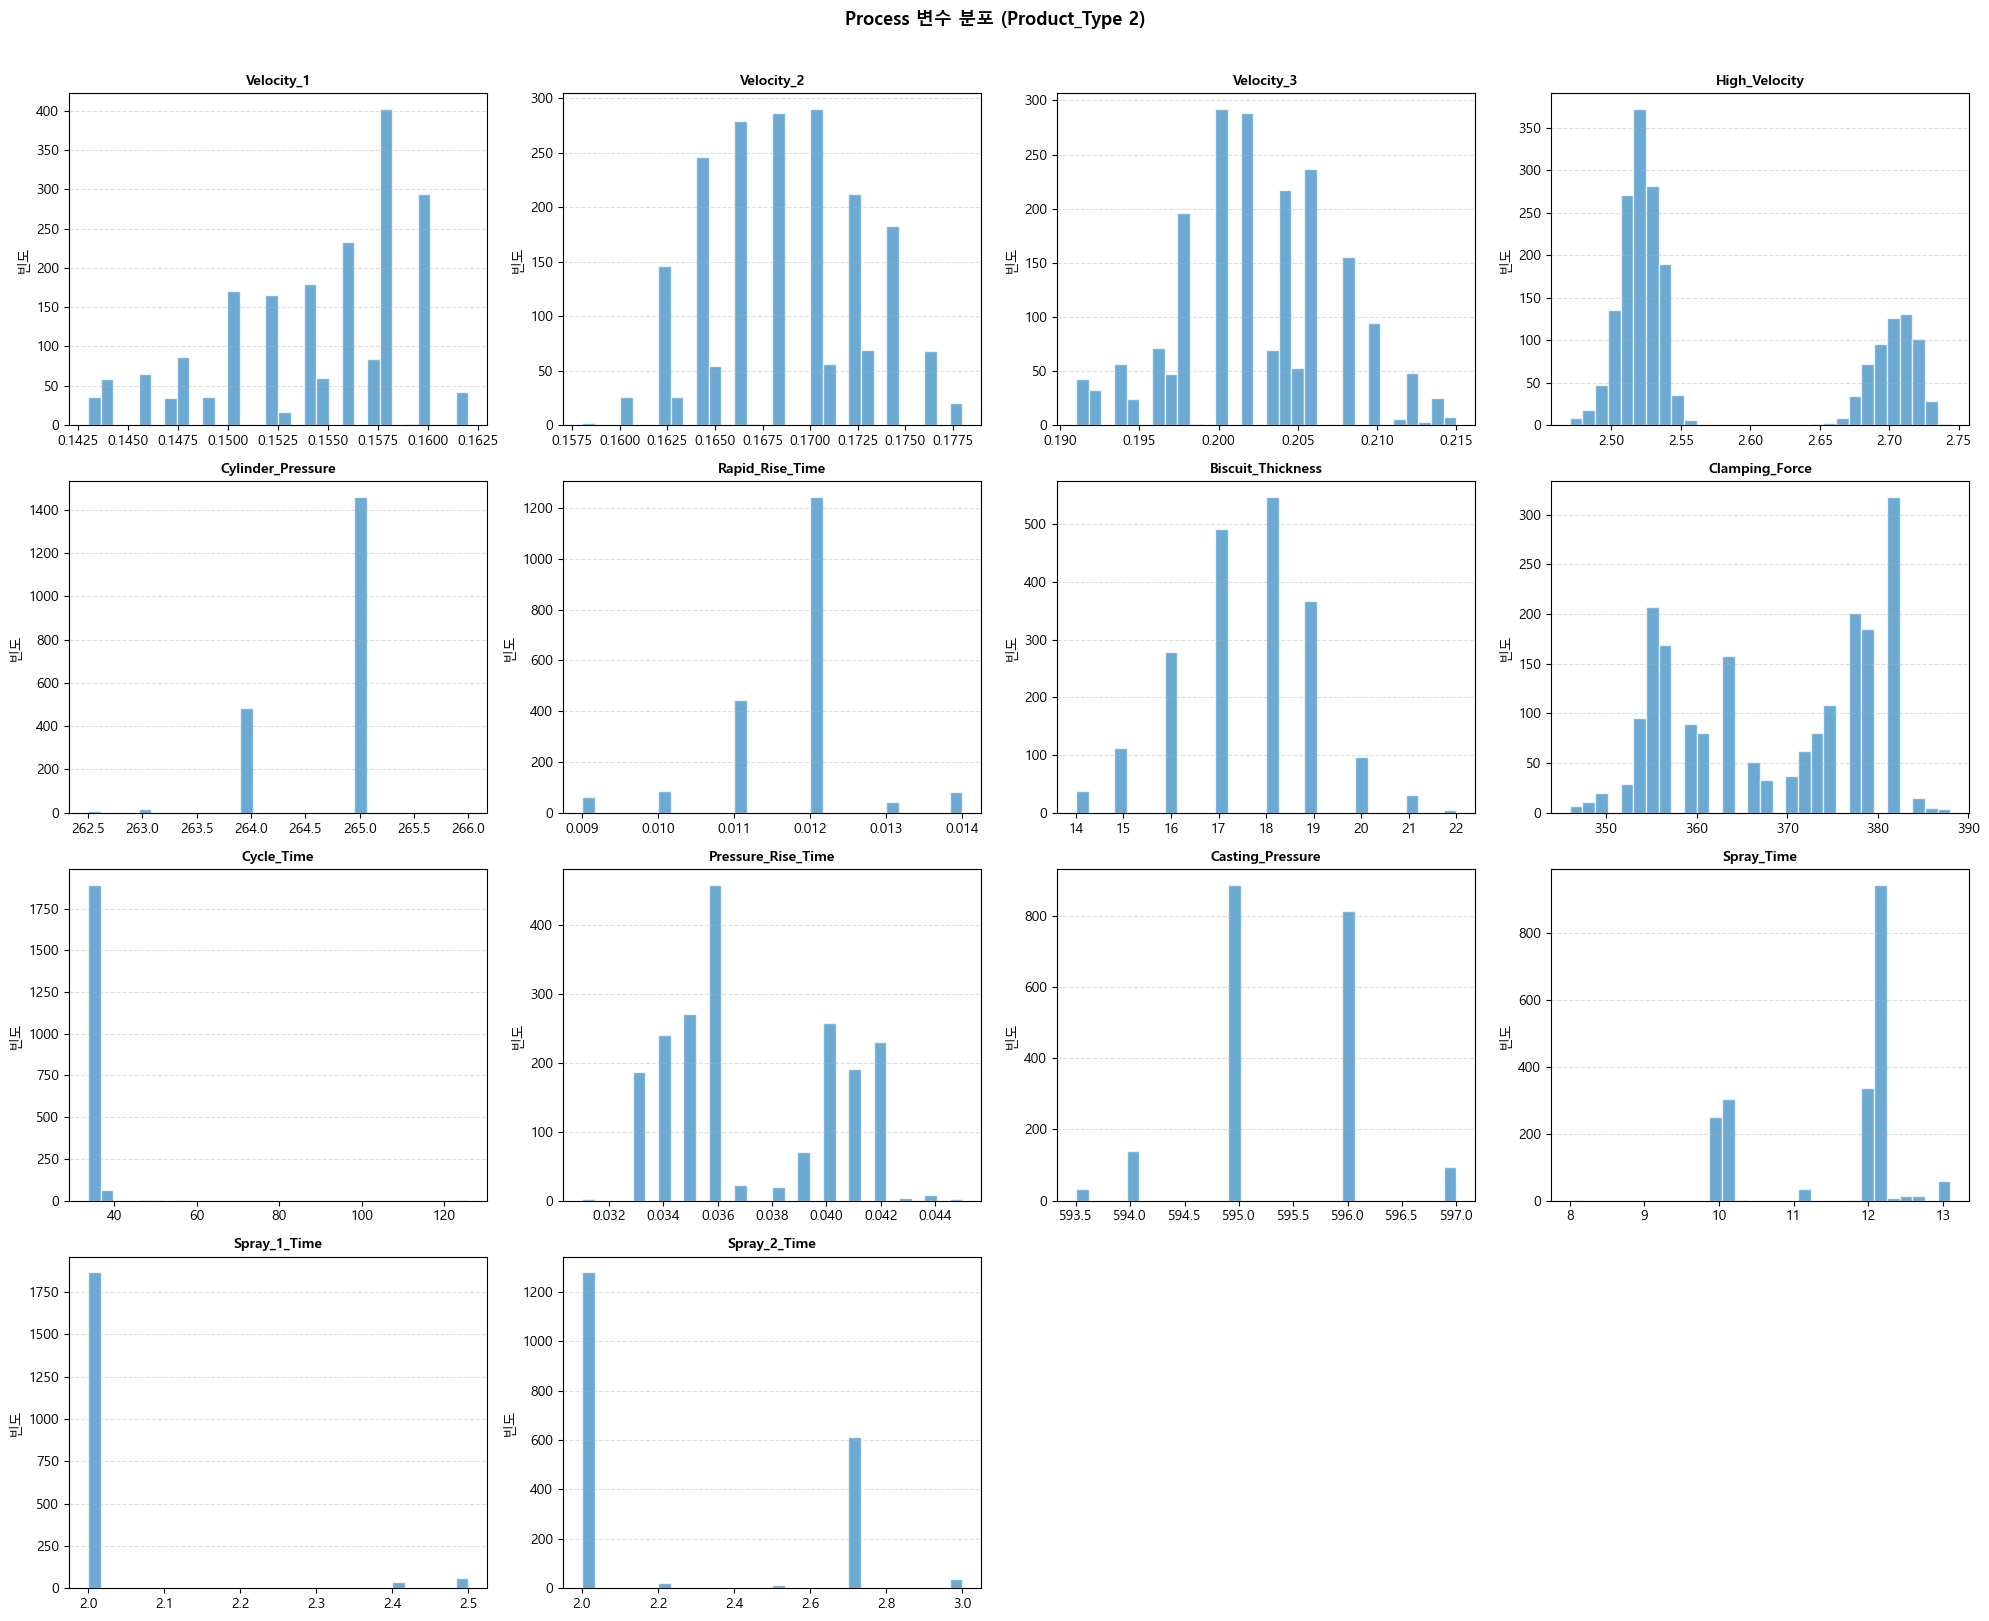

In [18]:
# Process 변수 히스토그램 + 박스플롯
n_cols, n_rows = 4, (len(process_num_cols) + 3) // 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(process_num_cols):
    axes[i].hist(df_drop[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Process 변수 분포 (Product_Type 2)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [19]:
df_drop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Type               1964 non-null   int64  
 1   Shot                       1964 non-null   int64  
 2   Velocity_1                 1964 non-null   float64
 3   Velocity_2                 1964 non-null   float64
 4   Velocity_3                 1964 non-null   float64
 5   High_Velocity              1964 non-null   float64
 6   Cylinder_Pressure          1964 non-null   float64
 7   Rapid_Rise_Time            1964 non-null   float64
 8   Biscuit_Thickness          1964 non-null   int64  
 9   Clamping_Force             1964 non-null   int64  
 10  Cycle_Time                 1964 non-null   float64
 11  Pressure_Rise_Time         1964 non-null   float64
 12  Casting_Pressure           1964 non-null   float64
 13  Spray_Time                 1964 non-null   float64
 14  Spr

In [20]:
df_drop['Defect_Type'].value_counts()

Defect_Type
Normal        1467
Short_Shot     222
Blow_Hole      169
Stain           70
Other           35
Bubble           1
Name: count, dtype: int64

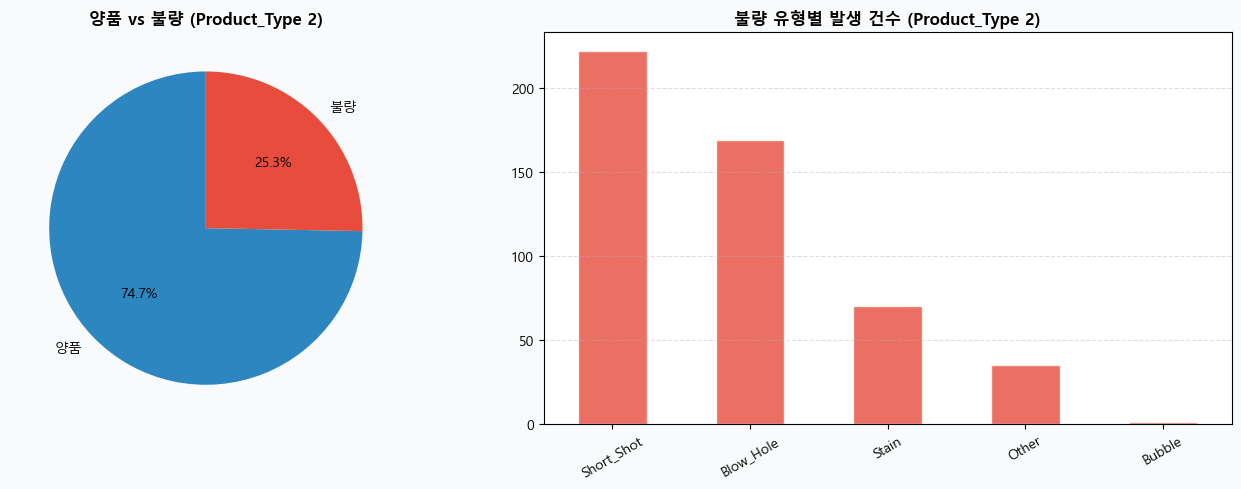

In [21]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = df_drop['Defect_Status'].value_counts()
axes[0].pie(sizes, labels=['양품','불량'], autopct='%1.1f%%',
            colors=['#2E86C1','#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 2)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = df_drop[df_drop['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 2)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [22]:
df_drop.info()

<class 'pandas.DataFrame'>
RangeIndex: 1964 entries, 0 to 1963
Data columns (total 47 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Type               1964 non-null   int64  
 1   Shot                       1964 non-null   int64  
 2   Velocity_1                 1964 non-null   float64
 3   Velocity_2                 1964 non-null   float64
 4   Velocity_3                 1964 non-null   float64
 5   High_Velocity              1964 non-null   float64
 6   Cylinder_Pressure          1964 non-null   float64
 7   Rapid_Rise_Time            1964 non-null   float64
 8   Biscuit_Thickness          1964 non-null   int64  
 9   Clamping_Force             1964 non-null   int64  
 10  Cycle_Time                 1964 non-null   float64
 11  Pressure_Rise_Time         1964 non-null   float64
 12  Casting_Pressure           1964 non-null   float64
 13  Spray_Time                 1964 non-null   float64
 14  Spr

## 전처리 완료 데이터 저장

In [23]:
save_cols = (
    ['Product_Type','Shot']
    + process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp',
       'Coolant_Pressure','Factory_Temp','Factory_Humidity']
    + ['Pressure_Difference', 'Pressure_Difference_Ratio']
    + ['Velocity_2-1','Velocity_3-2', 'Velocity_High-3', 'Velocity_Max-Min']
    + ['Defect_Status','Defect_Type']
)
df_clean = df_drop[save_cols].copy()
df_clean.to_csv('DieCasting_Preprocessed_Type2.csv', index=False)

print(f"✅ 저장 완료: DieCasting_Preprocessed_Type2.csv")
print(f"   최종 Shape: {df_clean.shape[0]}행 × {df_clean.shape[1]}열")
df_clean.head(3)

✅ 저장 완료: DieCasting_Preprocessed_Type2.csv
   최종 Shape: 1964행 × 30열


,Product_Type,Shot,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Cylinder_Pressure,Rapid_Rise_Time,Biscuit_Thickness,Clamping_Force,Cycle_Time,Pressure_Rise_Time,Casting_Pressure,Spray_Time,Spray_1_Time,Spray_2_Time,Melting_Furnace_Temp,Air_Pressure,Coolant_Temp,Coolant_Pressure,Factory_Temp,Factory_Humidity,Pressure_Difference,Pressure_Difference_Ratio,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min,Defect_Status,Defect_Type
0,2,11,0.156,0.166,0.192,2.723,265.0,0.012,20,357,36.6,0.041,595.0,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,330,2.245283,0.010,0.026,2.531,2.567,0,Normal
1,2,12,0.157,0.166,0.204,2.730,264.0,0.014,19,359,36.5,0.040,594.0,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,330,2.250000,0.009,0.038,2.526,2.573,0,Normal
2,2,13,0.156,0.170,0.204,2.715,265.0,0.012,18,361,36.5,0.041,595.0,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,330,2.245283,0.014,0.034,2.511,2.559,0,Normal


## 상관분석 — Defect_Status와의 Spearman 상관계수

> Product_Type 2 데이터에 대해서만 상관분석 진행

In [24]:
analysis_features = (
    process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
       'Factory_Temp','Factory_Humidity']
    + ['Pressure_Difference', 'Pressure_Difference_Ratio']
    + ['Velocity_2-1','Velocity_3-2', 'Velocity_High-3', 'Velocity_Max-Min']
)

# 분산=0 변수는 상관분석에서도 제외
analysis_features = [f for f in analysis_features if f not in zero_var_cols]

# Spearman 상관계수 계산
corr_series = df_drop[analysis_features + ['Defect_Status']].corr(method='spearman')['Defect_Status'].drop('Defect_Status')

corr_df = pd.DataFrame({
    'variable':    corr_series.index,
    'correlation': corr_series.values,
    'abs_corr':    corr_series.abs().values
}).sort_values('abs_corr', ascending=False).reset_index(drop=True)

corr_df.insert(0, 'rank', range(1, len(corr_df)+1))

print("📊 Defect_Status와의 Spearman 상관계수 전체 순위 (Product_Type 2):")
if zero_var_cols:
    print(f"   (분산=0으로 제외된 변수: {zero_var_cols})")
display(corr_df)


📊 Defect_Status와의 Spearman 상관계수 전체 순위 (Product_Type 2):
   (분산=0으로 제외된 변수: ['Spray_1_Time'])


,rank,variable,correlation,abs_corr
0,1,High_Velocity,-0.233290,0.233290
1,2,Velocity_Max-Min,-0.220125,0.220125
2,3,Velocity_High-3,-0.219916,0.219916
3,4,Factory_Temp,-0.201040,0.201040
4,5,Spray_2_Time,-0.188109,0.188109
5,6,Clamping_Force,0.165690,0.165690
6,7,Spray_Time,0.165356,0.165356
7,8,Coolant_Pressure,0.158175,0.158175
8,9,Pressure_Rise_Time,-0.145449,0.145449
9,10,Cylinder_Pressure,0.128826,0.128826


> 제조업 기준으로 상관계수 범위를 어떻게 봐야할지?? 잠깐 찾아보니 0.2 기준도 괜찮다고는 하는데 더 찾아봐야 할 듯!

### ⚠️ 상관계수 NaN 변수 처리
> 상관계수가 NaN인 변수 = 분산이 0 (상수값) → 예측에 기여 불가
> 모델 피처에서 제거 필요

In [25]:
# NaN 상관계수 잔여 확인 (분산=0 변수를 Capping 전에 제거했으므로 NaN 없어야 함)
nan_vars = corr_df[corr_df['correlation'].isna()]['variable'].tolist()

if not nan_vars:
    print("✅ NaN 상관계수 없음 — 분산=0 변수 사전 제거 효과")
else:
    print(f"⚠️ 잔여 NaN 변수: {nan_vars}")
    for col in nan_vars:
        print(f"   {col}: 고유값={df_drop[col].nunique()}, std={df_drop[col].std():.6f}")

✅ NaN 상관계수 없음 — 분산=0 변수 사전 제거 효과


In [26]:
# 분산=0 변수 제거 (Capping 단계에서 이미 cap_cols에서 제외됨 — 여기서 FEATURES에도 반영)
print(f"분산=0으로 제거된 변수: {zero_var_cols}")

FEATURES = [f for f in (
    process_num_cols
    + ['Melting_Furnace_Temp','Air_Pressure','Coolant_Temp','Coolant_Pressure',
       'Factory_Temp','Factory_Humidity']
    + ['Velocity_Avg','Pressure_Difference', 'Pressure_Difference_Ratio','Coolant_Temp_Range']
) if f not in zero_var_cols]

print(f"\n✅ 정제된 피처 수: {len(FEATURES)}개")
print(f"   사용 피처: {FEATURES}")


분산=0으로 제거된 변수: ['Spray_1_Time']

✅ 정제된 피처 수: 23개
   사용 피처: ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Difference', 'Pressure_Difference_Ratio', 'Coolant_Temp_Range']


### 다중공선성 (Pressure)

In [27]:
# 다중공선성 확인 — Casting_Pressure / Cylinder_Pressure / Pressure_Difference / Pressure_Difference_Ratio
high_corr_vars = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference', 'Pressure_Difference_Ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars].corr().round(3))

[ 다중공선성 의심 변수 상관관계 ]


,Casting_Pressure,Cylinder_Pressure,Pressure_Difference,Pressure_Difference_Ratio
Casting_Pressure,1.000,0.647,0.589,0.135
Cylinder_Pressure,0.647,1.000,0.205,-0.639
Pressure_Difference,0.589,0.205,1.000,0.427
Pressure_Difference_Ratio,0.135,-0.639,0.427,1.000


> 지금은 괜찮은데 모델링 할 때 제거?

In [28]:
# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_drop[high_corr_vars]

vif_df = pd.DataFrame()
vif_df["variable"] = X.columns
vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df)

                    variable           VIF
0           Casting_Pressure  3.457892e+06
1          Cylinder_Pressure  1.121719e+06
2        Pressure_Difference  2.068640e+05
3  Pressure_Difference_Ratio  7.143455e+05


> 값이 엄청 큰데, 이는 선형 종속 관계일 가능성?  (VIF >= 10: 이상이 있다라고 간주)  
> Cylinder_Pressure, Casting_Pressure, Pressure_Difference 는 사용하지 않고, Pressure_Difference_Ratio 만 사용

In [29]:
# 다중공선성 확인 — Velocity_1 / Velocity_2 / Velocity_3
high_corr_vars5 = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Casting_Pressure', 'Cylinder_Pressure']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars5].corr().round(3))

# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_drop[high_corr_vars5]

vif_df5 = pd.DataFrame()
vif_df5["variable"] = X.columns
vif_df5["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df5)

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Casting_Pressure,Cylinder_Pressure
Velocity_1,1.000,-0.050,-0.018,0.013,-0.004,-0.039
Velocity_2,-0.050,1.000,-0.021,-0.167,0.060,0.061
Velocity_3,-0.018,-0.021,1.000,0.091,-0.118,-0.109
High_Velocity,0.013,-0.167,0.091,1.000,-0.381,-0.405
Casting_Pressure,-0.004,0.060,-0.118,-0.381,1.000,0.647
Cylinder_Pressure,-0.039,0.061,-0.109,-0.405,0.647,1.000


            variable            VIF
0         Velocity_1    1061.080484
1         Velocity_2    1753.770362
2         Velocity_3    1672.357480
3      High_Velocity     939.927604
4   Casting_Pressure  568544.946748
5  Cylinder_Pressure  552059.315650


In [30]:
# 다중공선성 확인 — Velocity_1 / Velocity_2 / Velocity_3
high_corr_vars6 = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Pressure_Difference_Ratio']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars6].corr().round(3))

# VIF도 확인

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_drop[high_corr_vars6]

vif_df6 = pd.DataFrame()
vif_df6["variable"] = X.columns
vif_df6["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df6)

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Pressure_Difference_Ratio
Velocity_1,1.000,-0.050,-0.018,0.013,0.034
Velocity_2,-0.050,1.000,-0.021,-0.167,-0.020
Velocity_3,-0.018,-0.021,1.000,0.091,0.024
High_Velocity,0.013,-0.167,0.091,1.000,0.176
Pressure_Difference_Ratio,0.034,-0.020,0.024,0.176,1.000


                    variable          VIF
0                 Velocity_1  1061.907596
1                 Velocity_2  1755.275394
2                 Velocity_3  1685.495598
3              High_Velocity   952.017660
4  Pressure_Difference_Ratio  5892.125378


In [31]:
multicollinear_cols = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference']

df_drop = df_drop.drop(columns=multicollinear_cols)

### 다중공선성(Velocity)

In [32]:
# 다중공선성 확인 — Velocity_1 / Velocity_2 / Velocity_3 / High_Velocity / Velocity_2-1 / Velocity_3-2 / Velocity_High-3 / Velocity_Max-Min
high_corr_vars2 = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Velocity_2-1', 'Velocity_3-2', 'Velocity_High-3', 'Velocity_Max-Min']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars2].corr().round(3))

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity,Velocity_2-1,Velocity_3-2,Velocity_High-3,Velocity_Max-Min
Velocity_1,1.000,-0.050,-0.018,0.013,-0.776,0.017,0.014,-0.043
Velocity_2,-0.050,1.000,-0.021,-0.167,0.667,-0.634,-0.167,-0.164
Velocity_3,-0.018,-0.021,1.000,0.091,0.002,0.783,0.032,0.093
High_Velocity,0.013,-0.167,0.091,1.000,-0.114,0.172,0.998,0.998
Velocity_2-1,-0.776,0.667,0.002,-0.114,1.000,-0.411,-0.115,-0.070
Velocity_3-2,0.017,-0.634,0.783,0.172,-0.411,1.000,0.126,0.171
Velocity_High-3,0.014,-0.167,0.032,0.998,-0.115,0.126,1.000,0.997
Velocity_Max-Min,-0.043,-0.164,0.093,0.998,-0.070,0.171,0.997,1.000


In [33]:
# # VIF도 확인

# from statsmodels.stats.outliers_influence import variance_inflation_factor

# X = df_drop[high_corr_vars2]

# vif_df2 = pd.DataFrame()
# vif_df2["variable"] = X.columns
# vif_df2["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# print(vif_df2)

In [34]:
# 다중공선성 확인 — Velocity_1 / Velocity_2 / Velocity_3 / High_Velocity
high_corr_vars3 = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars3].corr().round(3))

# VIF도 확인 (Velocity_1, 2, 3, High 만)

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_drop[high_corr_vars3]

vif_df3 = pd.DataFrame()
vif_df3["variable"] = X.columns
vif_df3["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df3)

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_1,Velocity_2,Velocity_3,High_Velocity
Velocity_1,1.000,-0.050,-0.018,0.013
Velocity_2,-0.050,1.000,-0.021,-0.167
Velocity_3,-0.018,-0.021,1.000,0.091
High_Velocity,0.013,-0.167,0.091,1.000


        variable          VIF
0     Velocity_1   836.056799
1     Velocity_2  1040.640879
2     Velocity_3  1242.981159
3  High_Velocity   756.604436


In [35]:
# 다중공선성 확인 — Velocity_2-1 / Velocity_3-2 / Velocity_High-3
high_corr_vars4 = ['Velocity_2-1', 'Velocity_3-2', 'Velocity_High-3']
print("[ 다중공선성 의심 변수 상관관계 ]")
display(df_drop[high_corr_vars4].corr().round(3))

# VIF도 확인 (Velocity_1, 2, 3, High 만)

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_drop[high_corr_vars4]

vif_df4 = pd.DataFrame()
vif_df4["variable"] = X.columns
vif_df4["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_df4)

[ 다중공선성 의심 변수 상관관계 ]


,Velocity_2-1,Velocity_3-2,Velocity_High-3
Velocity_2-1,1.000,-0.411,-0.115
Velocity_3-2,-0.411,1.000,0.126
Velocity_High-3,-0.115,0.126,1.000


          variable        VIF
0     Velocity_2-1   6.456226
1     Velocity_3-2  32.692113
2  Velocity_High-3  47.698257


In [36]:
# multicollinear_cols = ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference']

# df_drop = df_drop.drop(columns=multicollinear_cols)

### 다중공선성 최종 정리

In [37]:
# 다중공선성 변수 정리 — Casting_Pressure, Cylinder_Pressure, Pressure_Difference 제거

FEATURES = [f for f in FEATURES if f not in multicollinear_cols]

print(f"✅ 다중공선성 제거 후 최종 피처 수: {len(FEATURES)}개")
print(f"   제거: {multicollinear_cols}")
print(f"   유지: Pressure_Diff (두 압력의 차이 = 실질 정보)")
print(f"\n최종 FEATURES: {FEATURES}")

✅ 다중공선성 제거 후 최종 피처 수: 20개
   제거: ['Casting_Pressure', 'Cylinder_Pressure', 'Pressure_Difference']
   유지: Pressure_Diff (두 압력의 차이 = 실질 정보)

최종 FEATURES: ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity', 'Rapid_Rise_Time', 'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time', 'Pressure_Rise_Time', 'Spray_Time', 'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp', 'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Velocity_Avg', 'Pressure_Difference_Ratio', 'Coolant_Temp_Range']


In [38]:
top10 = corr_df.head(10).copy()
print("🏆 TOP 10 변수 (|상관계수| 기준)")
print("-" * 50)
for _, row in top10.iterrows():
    direction = "▼ 불량 감소" if row['correlation'] < 0 else "▲ 불량 증가"
    print(f"  #{int(row['rank']):2d}  {row['variable']:<25}  {row['correlation']:+.4f}  {direction}")

🏆 TOP 10 변수 (|상관계수| 기준)
--------------------------------------------------
  # 1  High_Velocity              -0.2333  ▼ 불량 감소
  # 2  Velocity_Max-Min           -0.2201  ▼ 불량 감소
  # 3  Velocity_High-3            -0.2199  ▼ 불량 감소
  # 4  Factory_Temp               -0.2010  ▼ 불량 감소
  # 5  Spray_2_Time               -0.1881  ▼ 불량 감소
  # 6  Clamping_Force             +0.1657  ▲ 불량 증가
  # 7  Spray_Time                 +0.1654  ▲ 불량 증가
  # 8  Coolant_Pressure           +0.1582  ▲ 불량 증가
  # 9  Pressure_Rise_Time         -0.1454  ▼ 불량 감소
  #10  Cylinder_Pressure          +0.1288  ▲ 불량 증가


> 불량 발생은 압력보다 충진 속도의 영향이 더 크며,  
> High_Velocity가 충분하지 않을 때 충진 안정성이 떨어져  
> 불량 발생 가능성이 증가하는 패턴??

히트맵에서 제외된 변수(데이터에 없음): ['Cylinder_Pressure']


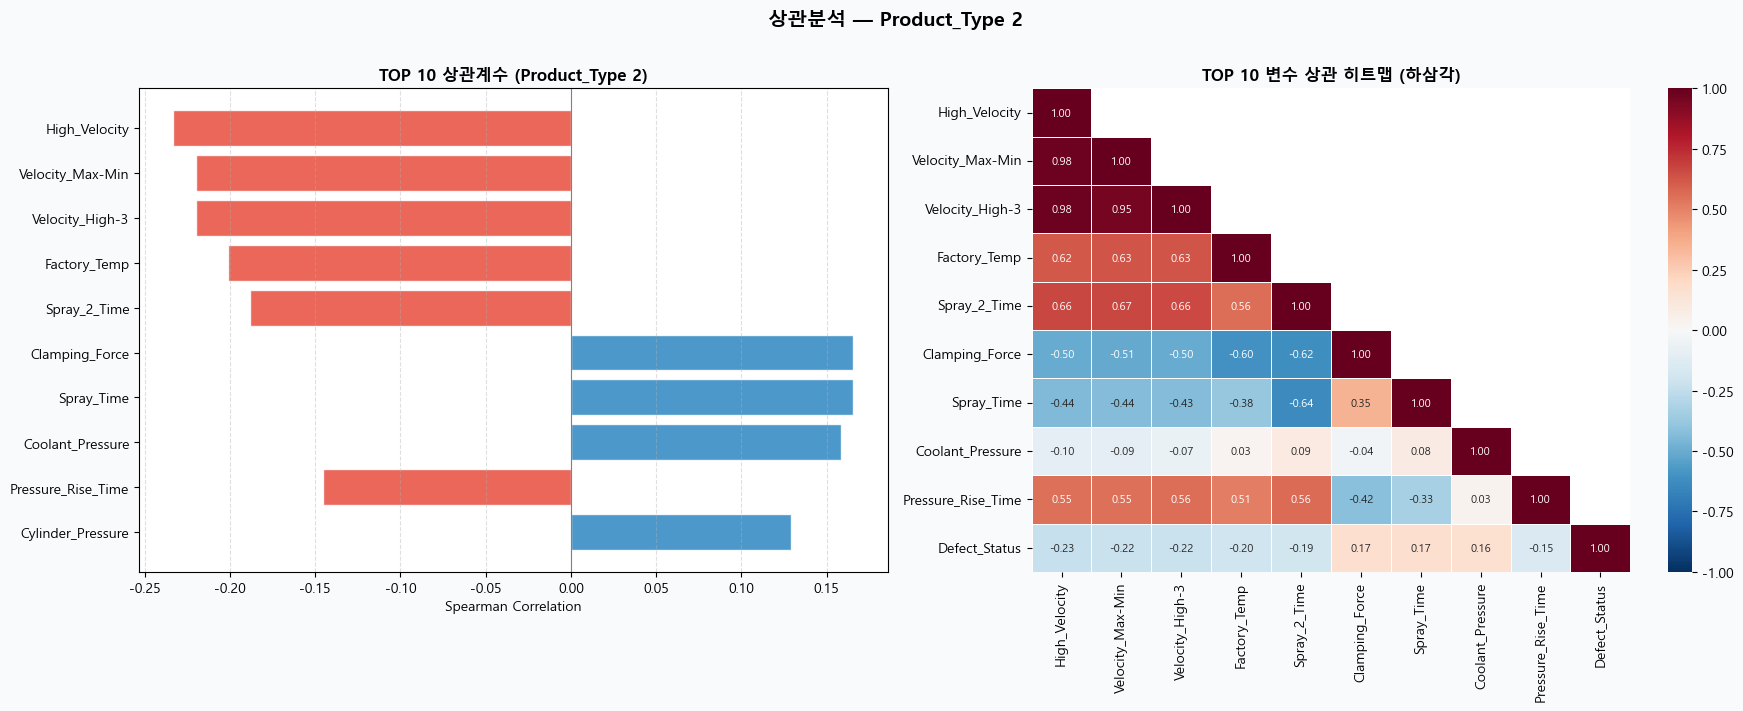

In [39]:
# 상관계수 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7), facecolor='#F8FAFB')

# 바 차트
colors = ['#E74C3C' if v < 0 else '#2E86C1' for v in top10['correlation']]
axes[0].barh(top10['variable'][::-1], top10['correlation'][::-1],
             color=colors[::-1], alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='gray', lw=0.8)
axes[0].set_title('TOP 10 상관계수 (Product_Type 2)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spearman Correlation')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)


# 히트맵에 쓸 변수(존재하는 것만)
top10_vars = top10['variable'].tolist()
top10_vars_exist = [c for c in top10_vars if c in df_drop.columns]

# 어떤 변수가 빠졌는지 로그로 확인
missing = sorted(set(top10_vars) - set(top10_vars_exist))
print("히트맵에서 제외된 변수(데이터에 없음):", missing)

# Spearman으로 통일 (Defect_Status 포함)
corr_matrix = df_drop[top10_vars_exist + ['Defect_Status']].corr(method='spearman')

# 히트맵
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, ax=axes[1], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot_kws={'size': 8}, linewidths=0.5)
axes[1].set_title('TOP 10 변수 상관 히트맵 (하삼각)', fontsize=12, fontweight='bold')

plt.suptitle('상관분석 — Product_Type 2', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 🤖 모델링 파이프라인 (Product_Type 1)
> **목표**: Recall ≥ 0.80 유지하면서 F1-Score 최대화

> **SMOTE 미적용** — class_weight / scale_pos_weight로 불균형 대응

## 모델링 라이브러리 환경 설정

In [40]:
# 모델링
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, f1_score, recall_score, precision_score,
    precision_recall_curve, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import shap
import pickle

SEED = 42
np.random.seed(SEED)
print("✅ 모델링 라이브러리 로드 완료")

✅ 모델링 라이브러리 로드 완료
